In [1]:
import pandas as pd
import xarray as xr
import glob
import os
from itertools import product
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LassoCV, LassoLarsCV
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.pipeline import Pipeline
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import random

In [2]:
onset_files = sorted(glob.glob(os.path.expandvars("$SCRATCH/onset/*.nc4")))
precipitation = xr.open_mfdataset(onset_files, combine="by_coords").sel(lat=slice(0, 6), lon=slice(37, 48))
precipitation

/tmp/ipykernel_259900/3768583634.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  precipitation = xr.open_mfdataset(onset_files, combine="by_coords").sel(lat=slice(0, 6), lon=slice(37, 48))


<xarray.Dataset> Size: 24MB
Dimensions:                     (time: 8035, lon: 12, lat: 7)
Coordinates:
  * time                        (time) datetime64[ns] 64kB 2001-01-01 ... 202...
  * lon                         (lon) int64 96B 37 38 39 40 41 ... 45 46 47 48
  * lat                         (lat) int64 56B 0 1 2 3 4 5 6
Data variables:
    precipitation               (time, lon, lat) float32 3MB dask.array<chunksize=(365, 12, 7), meta=np.ndarray>
    rainy_season_onset          (time, lon, lat) float64 5MB dask.array<chunksize=(365, 12, 7), meta=np.ndarray>
    rainy_season_onset_h2       (time, lon, lat) float64 5MB dask.array<chunksize=(365, 12, 7), meta=np.ndarray>
    rainy_season_onset_date     (time, lon, lat) datetime64[ns] 5MB dask.array<chunksize=(365, 12, 7), meta=np.ndarray>
    rainy_season_onset_date_h2  (time, lon, lat) datetime64[ns] 5MB dask.array<chunksize=(365, 12, 7), meta=np.ndarray>

In [3]:
sm_files = sorted(glob.glob(os.path.expandvars("$SCRATCH/soil_moisture/*.nc4")))
sm = xr.open_mfdataset(sm_files, combine="by_coords").sel(lat=slice(0, 6), lon=slice(37, 48))
sm

<xarray.Dataset> Size: 3MB
Dimensions:                  (time: 2555, lat: 7, lon: 12)
Coordinates:
  * time                     (time) datetime64[ns] 20kB 2016-01-01 ... 2022-1...
  * lat                      (lat) int64 56B 0 1 2 3 4 5 6
  * lon                      (lon) int64 96B 37 38 39 40 41 42 43 44 45 46 47 48
Data variables:
    soil_moisture            (time, lat, lon) float64 2MB dask.array<chunksize=(365, 7, 12), meta=np.ndarray>
    root_zone_soil_moisture  (time, lat, lon) float64 2MB dask.array<chunksize=(365, 7, 12), meta=np.ndarray>

In [4]:
sst_files = sorted(glob.glob(os.path.expandvars("$SCRATCH/sst/*.nc4")))
sst = xr.open_mfdataset(sst_files, combine="by_coords").sel(lat=slice(-15, 5), lon=slice(45, 60))
sst

<xarray.Dataset> Size: 43MB
Dimensions:   (time: 8035, lat: 21, lon: 16)
Coordinates:
  * time      (time) datetime64[ns] 64kB 2001-01-01 2001-01-02 ... 2022-12-31
  * lat       (lat) int64 168B -15 -14 -13 -12 -11 -10 -9 -8 ... -1 0 1 2 3 4 5
  * lon       (lon) int64 128B 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60
Data variables:
    SSTK      (time, lat, lon) float32 11MB dask.array<chunksize=(365, 21, 16), meta=np.ndarray>
    utc_date  (time, lat, lon) float64 22MB dask.array<chunksize=(365, 21, 16), meta=np.ndarray>
    SSTC      (time, lat, lon) float32 11MB dask.array<chunksize=(365, 21, 16), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.3
    CONVERSION_PLATFORM:  Linux r10i4n16 4.12.14-94.41-default #1 SMP Wed Oct...
    CONVERSION_DATE:      Sun Jul 28 08:40:56 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Sun Jul 28 08:41:12 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.9 (Homepage = http://n...

In [5]:
ocean_files = sorted(glob.glob(os.path.expandvars("$SCRATCH/era5_ocean/*.nc4")))
ocean = xr.open_mfdataset(ocean_files, combine="by_coords").sel(lat=slice(-15, 5), lon=slice(45, 60))
ocean

<xarray.Dataset> Size: 21MB
Dimensions:   (time: 2557, lat: 21, lon: 16)
Coordinates:
  * time      (time) datetime64[ns] 20kB 2016-01-01 2016-01-02 ... 2022-12-31
  * lat       (lat) int64 168B -15 -14 -13 -12 -11 -10 -9 -8 ... -1 0 1 2 3 4 5
  * lon       (lon) int64 128B 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60
Data variables:
    TCWV      (time, lat, lon) float32 3MB dask.array<chunksize=(366, 21, 16), meta=np.ndarray>
    MSL       (time, lat, lon) float32 3MB dask.array<chunksize=(366, 21, 16), meta=np.ndarray>
    VAR_10U   (time, lat, lon) float32 3MB dask.array<chunksize=(366, 21, 16), meta=np.ndarray>
    VAR_10V   (time, lat, lon) float32 3MB dask.array<chunksize=(366, 21, 16), meta=np.ndarray>
    utc_date  (time, lat, lon) float64 7MB dask.array<chunksize=(366, 21, 16), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.3
    CONVERSION_PLATFORM:  Linux r8i6n32 4.12.14-94.41-default #1 SMP Wed Oct ...
    CONVERSION_DATE:      Mon Sep  2 11:19:21 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Mon Sep  2 11:19:38 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.9 (Homepage = http://n...

In [6]:
land_files = sorted(glob.glob(os.path.expandvars("$SCRATCH/era5_land/*.nc4")))
land = xr.open_mfdataset(land_files, combine="by_coords").sel(lat=slice(0, 6), lon=slice(37, 48))
land

<xarray.Dataset> Size: 5MB
Dimensions:   (time: 2557, lat: 7, lon: 12)
Coordinates:
  * time      (time) datetime64[ns] 20kB 2016-01-01 2016-01-02 ... 2022-12-31
  * lat       (lat) int64 56B 0 1 2 3 4 5 6
  * lon       (lon) int64 96B 37 38 39 40 41 42 43 44 45 46 47 48
Data variables:
    VAR_2T    (time, lat, lon) float32 859kB dask.array<chunksize=(366, 7, 12), meta=np.ndarray>
    VAR_2D    (time, lat, lon) float32 859kB dask.array<chunksize=(366, 7, 12), meta=np.ndarray>
    CAPE      (time, lat, lon) float32 859kB dask.array<chunksize=(366, 7, 12), meta=np.ndarray>
    TCC       (time, lat, lon) float32 859kB dask.array<chunksize=(366, 7, 12), meta=np.ndarray>
    utc_date  (time, lat, lon) float64 2MB dask.array<chunksize=(366, 7, 12), meta=np.ndarray>
Attributes:
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.6.3
    CONVERSION_PLATFORM:  Linux r8i6n32 4.12.14-94.41-default #1 SMP Wed Oct ...
    CONVERSION_DATE:      Mon Sep  2 11:44:30 MDT 2019
    Conventions:          CF-1.6
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    history:              Mon Sep  2 11:44:47 2019: ncks -4 --ppc default=7 e...
    NCO:                  netCDF Operators version 4.7.9 (Homepage = http://n...

In [7]:
years = np.arange(2016, 2023)
sm_lat = sm["lat"].values
sm_lon = sm["lon"].values
ond_onsets = []
sep_precip_dekad1 = []
sep_sst_dekad1 = []
sep_sm_dekad1 = []
sep_rzsm_dekad1 = []
onset_years = []
lats = []
lons = []
aug_precip_dekad1, aug_precip_dekad2, aug_precip_dekad3 = [], [], []
aug_sst_dekad1,    aug_sst_dekad2,    aug_sst_dekad3    = [], [], []
aug_sm_dekad1,     aug_sm_dekad2,     aug_sm_dekad3     = [], [], []
aug_rzsm_dekad1,   aug_rzsm_dekad2,   aug_rzsm_dekad3   = [], [], []
sep_tcwv_dekad1 = []
sep_msl_dekad1 = []
sep_10u_dekad1 = []
sep_10v_dekad1 = []
sep_2t_dekad1 = []
sep_2d_dekad1 = []
sep_cape_dekad1 = []
sep_tcc_dekad1 = []
for year in years:
    dekads = {
        "aug_dekad1": (f"{year}-08-01", f"{year}-08-10"),
        "aug_dekad2": (f"{year}-08-11", f"{year}-08-20"),
        "aug_dekad3": (f"{year}-08-21", f"{year}-08-31"),
        "sep_dekad1": (f"{year}-09-01", f"{year}-09-10"),
        "sep_dekad2": (f"{year}-09-11", f"{year}-09-20"),
        "sep_dekad3": (f"{year}-09-21", f"{year}-09-30"),
    }
    for lat, lon in product(sm_lat, sm_lon):
        onset = np.unique(precipitation["rainy_season_onset_h2"].sel(time=str(year), lat=lat, lon=lon))[0]
        if np.isfinite(onset):
            aug_sst_dekad1.append(float(np.nanmean(sst["SSTC"].sel(time=slice(*dekads["aug_dekad1"])))))
            aug_sst_dekad2.append(float(np.nanmean(sst["SSTC"].sel(time=slice(*dekads["aug_dekad2"])))))
            aug_sst_dekad3.append(float(np.nanmean(sst["SSTC"].sel(time=slice(*dekads["aug_dekad3"])))))
            aug_sm_dekad1.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["aug_dekad1"]), lat=lat, lon=lon))))
            aug_sm_dekad2.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["aug_dekad2"]), lat=lat, lon=lon))))
            aug_sm_dekad3.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["aug_dekad3"]), lat=lat, lon=lon))))
            aug_rzsm_dekad1.append(float(np.nanmean(sm["root_zone_soil_moisture"].sel(time=slice(*dekads["aug_dekad1"]), lat=lat, lon=lon))))
            aug_rzsm_dekad2.append(float(np.nanmean(sm["root_zone_soil_moisture"].sel(time=slice(*dekads["aug_dekad2"]), lat=lat, lon=lon))))
            aug_rzsm_dekad3.append(float(np.nanmean(sm["root_zone_soil_moisture"].sel(time=slice(*dekads["aug_dekad3"]), lat=lat, lon=lon))))
            aug_precip_dekad1.append(float(np.nanmean(precipitation["precipitation"].sel(time=slice(*dekads["aug_dekad1"]), lat=lat, lon=lon))))
            aug_precip_dekad2.append(float(np.nanmean(precipitation["precipitation"].sel(time=slice(*dekads["aug_dekad2"]), lat=lat, lon=lon))))
            aug_precip_dekad3.append(float(np.nanmean(precipitation["precipitation"].sel(time=slice(*dekads["aug_dekad3"]), lat=lat, lon=lon))))
            sep_sst_dekad1.append(float(np.nanmean(sst["SSTC"].sel(time=slice(*dekads["sep_dekad1"])))))
            sep_sm_dekad1.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            sep_rzsm_dekad1.append(float(np.nanmean(sm["root_zone_soil_moisture"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            sep_precip_dekad1.append(float(np.nanmean(precipitation["precipitation"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            sep_tcwv_dekad1.append(float(np.nanmean(ocean["TCWV"].sel(time=slice(*dekads["sep_dekad1"])))))
            sep_msl_dekad1.append(float(np.nanmean(ocean["MSL"].sel(time=slice(*dekads["sep_dekad1"])))))
            sep_10u_dekad1.append(float(np.nanmean(ocean["VAR_10U"].sel(time=slice(*dekads["sep_dekad1"])))))
            sep_10v_dekad1.append(float(np.nanmean(ocean["VAR_10V"].sel(time=slice(*dekads["sep_dekad1"])))))
            sep_2t_dekad1.append(float(np.nanmean(land["VAR_2T"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            sep_2d_dekad1.append(float(np.nanmean(land["VAR_2D"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            sep_cape_dekad1.append(float(np.nanmean(land["CAPE"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            sep_tcc_dekad1.append(float(np.nanmean(land["TCC"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
            ond_onsets.append(onset)
            onset_years.append(year)
            lats.append(lat)
            lons.append(lon)

/tmp/ipykernel_259900/2677956554.py:39: RuntimeWarning: Mean of empty slice
  aug_sm_dekad1.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["aug_dekad1"]), lat=lat, lon=lon))))
/tmp/ipykernel_259900/2677956554.py:40: RuntimeWarning: Mean of empty slice
  aug_sm_dekad2.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["aug_dekad2"]), lat=lat, lon=lon))))
/tmp/ipykernel_259900/2677956554.py:41: RuntimeWarning: Mean of empty slice
  aug_sm_dekad3.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["aug_dekad3"]), lat=lat, lon=lon))))
/tmp/ipykernel_259900/2677956554.py:49: RuntimeWarning: Mean of empty slice
  sep_sm_dekad1.append(float(np.nanmean(sm["soil_moisture"].sel(time=slice(*dekads["sep_dekad1"]), lat=lat, lon=lon))))
/tmp/ipykernel_259900/2677956554.py:42: RuntimeWarning: Mean of empty slice
  aug_rzsm_dekad1.append(float(np.nanmean(sm["root_zone_soil_moisture"].sel(time=slice(*dekads["aug_dekad1"]), lat=lat, lon=lon))))
/tmp/ipy

In [8]:
df = pd.DataFrame({
    "year": onset_years, "lat": lats, "lon": lons,
    "ond_onset": ond_onsets,
    # August
    "aug_sst_dekad1": aug_sst_dekad1, "aug_sst_dekad2": aug_sst_dekad2, "aug_sst_dekad3": aug_sst_dekad3,
    "aug_sm_dekad1":  aug_sm_dekad1,  "aug_sm_dekad2":  aug_sm_dekad2,  "aug_sm_dekad3":  aug_sm_dekad3,
    "aug_rzsm_dekad1":aug_rzsm_dekad1,"aug_rzsm_dekad2":aug_rzsm_dekad2,"aug_rzsm_dekad3":aug_rzsm_dekad3,
    "aug_precip_dekad1":aug_precip_dekad1,"aug_precip_dekad2":aug_precip_dekad2,"aug_precip_dekad3":aug_precip_dekad3,
    # September
    "sep_sst_dekad1": sep_sst_dekad1,
    "sep_sm_dekad1":  sep_sm_dekad1,
    "sep_rzsm_dekad1":sep_rzsm_dekad1,
    "sep_precip_dekad1":sep_precip_dekad1,
    "sep_tcwv_dekad1": sep_tcwv_dekad1,
    "sep_msl_dekad1": sep_msl_dekad1,
    "sep_10u_dekad1": sep_10u_dekad1,
    "sep_10v_dekad1": sep_10v_dekad1,
    "sep_2t_dekad1": sep_2t_dekad1,
    "sep_2d_dekad1": sep_2d_dekad1,
    "sep_cape_dekad1": sep_cape_dekad1,
    "sep_tcc_dekad1": sep_tcc_dekad1
})
df["sep_precip_dekad1_square_root"] = df["sep_precip_dekad1"] ** (1/2)
df["sep_sst_dekad1_square_root"] = df["sep_sst_dekad1"] ** (1/2)
df["sep_rzsm_dekad1_squared"] = df["sep_rzsm_dekad1"] ** (2)
df["lat_squared"] = df["lat"] ** (2)
df["lon_seventh_power"] = df["lon"] ** (7)
df = df[df["year"] >= 2016]
df

,year,lat,lon,ond_onset,aug_sst_dekad1,aug_sst_dekad2,aug_sst_dekad3,aug_sm_dekad1,aug_sm_dekad2,aug_sm_dekad3,...,sep_10v_dekad1,sep_2t_dekad1,sep_2d_dekad1,sep_cape_dekad1,sep_tcc_dekad1,sep_precip_dekad1_square_root,sep_sst_dekad1_square_root,sep_rzsm_dekad1_squared,lat_squared,lon_seventh_power
0,2016,0,37,321.0,25.758461,25.976295,25.932539,0.228731,0.167427,0.184908,...,6.183882,288.000000,282.588348,2.734798,0.532103,0.461633,5.068843,0.073734,0,94931877133
1,2016,0,38,319.0,25.758461,25.976295,25.932539,0.125633,0.127328,0.119901,...,6.183882,294.002289,285.747253,1.520085,0.534394,0.147023,5.068843,0.040705,0,114415582592
2,2016,0,39,319.0,25.758461,25.976295,25.932539,0.097402,0.102149,0.097898,...,6.183882,298.474243,288.751526,1.104329,0.529933,0.203130,5.068843,0.020662,0,137231006679
3,2016,0,40,319.0,25.758461,25.976295,25.932539,0.070866,0.078187,0.072828,...,6.183882,299.391937,290.245544,2.784635,0.559831,0.367627,5.068843,0.018919,0,163840000000
4,2016,0,41,319.0,25.758461,25.976295,25.932539,0.088641,0.096710,0.094879,...,6.183882,299.985321,291.000732,2.741862,0.494783,0.673035,5.068843,0.017913,0,194754273881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,2022,6,40,290.0,25.700027,25.649536,25.764727,0.205612,NaN,NaN,...,5.819326,296.744141,284.627991,10.955502,0.742653,1.477987,5.081719,0.034866,36,163840000000
380,2022,6,41,289.0,25.700027,25.649536,25.764727,0.177224,NaN,NaN,...,5.819326,299.988922,284.540070,0.796517,0.688710,0.273870,5.081719,0.022858,36,194754273881
381,2022,6,43,297.0,25.700027,25.649536,25.764727,0.113057,NaN,NaN,...,5.819326,301.878601,285.857117,0.888346,0.607233,0.033690,5.081719,0.017925,36,271818611107
382,2022,6,44,295.0,25.700027,25.649536,25.764727,0.109738,NaN,NaN,...,5.819326,302.023895,286.207825,2.351562,0.643410,0.023979,5.081719,0.017329,36,319277809664


In [9]:
url = "https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php"
tables = pd.read_html(url)
oni_raw = tables[8]
oni_raw.columns = ["Year", "DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ", "JJA", "JAS", "ASO", "SON", "OND", "NDJ"]
oni = oni_raw[oni_raw["Year"] != "Year"].copy()
oni["Year"] = pd.to_numeric(oni["Year"], errors="coerce")
oni = oni.dropna(subset=["Year"])
oni["Year"] = oni["Year"].astype(int)
season_cols = ["DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ", "JJA", "JAS", "ASO", "SON", "OND", "NDJ"]
oni[season_cols] = oni[season_cols].apply(pd.to_numeric, errors="coerce")
oni

,Year,DJF,JFM,FMA,MAM,AMJ,MJJ,JJA,JAS,ASO,SON,OND,NDJ
1,1950,-1.5,-1.3,-1.2,-1.2,-1.1,-0.9,-0.5,-0.4,-0.4,-0.4,-0.6,-0.8
2,1951,-0.8,-0.5,-0.2,0.2,0.4,0.6,0.7,0.9,1.0,1.2,1.0,0.8
3,1952,0.5,0.4,0.3,0.3,0.2,0.0,-0.1,0.0,0.2,0.1,0.0,0.1
4,1953,0.4,0.6,0.6,0.7,0.8,0.8,0.7,0.7,0.8,0.8,0.8,0.8
5,1954,0.8,0.5,0.0,-0.4,-0.5,-0.5,-0.6,-0.8,-0.9,-0.8,-0.7,-0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,2022,-0.8,-0.8,-0.9,-1.0,-0.9,-0.8,-0.8,-0.9,-1.0,-0.9,-0.8,-0.7
81,2023,-0.5,-0.3,0.0,0.3,0.6,0.8,1.1,1.4,1.6,1.8,2.0,2.1
82,2024,1.9,1.6,1.3,0.8,0.5,0.2,0.1,-0.1,-0.2,-0.2,-0.3,-0.4
83,2025,-0.4,-0.2,-0.1,0.0,0.0,0.0,-0.1,-0.3,-0.4,-0.5,-0.6,-0.5


In [10]:
df = df.merge(
    oni[["Year", "JJA", "MJJ", "JAS", "ASO", "SON", "OND"]].rename(columns={"Year": "year"}),
    on="year",
    how="left"
)
df

,year,lat,lon,ond_onset,aug_sst_dekad1,aug_sst_dekad2,aug_sst_dekad3,aug_sm_dekad1,aug_sm_dekad2,aug_sm_dekad3,...,sep_sst_dekad1_square_root,sep_rzsm_dekad1_squared,lat_squared,lon_seventh_power,JJA,MJJ,JAS,ASO,SON,OND
0,2016,0,37,321.0,25.758461,25.976295,25.932539,0.228731,0.167427,0.184908,...,5.068843,0.073734,0,94931877133,-0.3,0.0,-0.5,-0.6,-0.6,-0.6
1,2016,0,38,319.0,25.758461,25.976295,25.932539,0.125633,0.127328,0.119901,...,5.068843,0.040705,0,114415582592,-0.3,0.0,-0.5,-0.6,-0.6,-0.6
2,2016,0,39,319.0,25.758461,25.976295,25.932539,0.097402,0.102149,0.097898,...,5.068843,0.020662,0,137231006679,-0.3,0.0,-0.5,-0.6,-0.6,-0.6
3,2016,0,40,319.0,25.758461,25.976295,25.932539,0.070866,0.078187,0.072828,...,5.068843,0.018919,0,163840000000,-0.3,0.0,-0.5,-0.6,-0.6,-0.6
4,2016,0,41,319.0,25.758461,25.976295,25.932539,0.088641,0.096710,0.094879,...,5.068843,0.017913,0,194754273881,-0.3,0.0,-0.5,-0.6,-0.6,-0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,2022,6,40,290.0,25.700027,25.649536,25.764727,0.205612,NaN,NaN,...,5.081719,0.034866,36,163840000000,-0.8,-0.8,-0.9,-1.0,-0.9,-0.8
380,2022,6,41,289.0,25.700027,25.649536,25.764727,0.177224,NaN,NaN,...,5.081719,0.022858,36,194754273881,-0.8,-0.8,-0.9,-1.0,-0.9,-0.8
381,2022,6,43,297.0,25.700027,25.649536,25.764727,0.113057,NaN,NaN,...,5.081719,0.017925,36,271818611107,-0.8,-0.8,-0.9,-1.0,-0.9,-0.8
382,2022,6,44,295.0,25.700027,25.649536,25.764727,0.109738,NaN,NaN,...,5.081719,0.017329,36,319277809664,-0.8,-0.8,-0.9,-1.0,-0.9,-0.8


In [11]:
def run_lasso_model(df, feature_cols, target_col="ond_onset"):
    train_df = df[df['year'] < 2021][feature_cols + [target_col]].dropna().copy()
    test_df = df[(df['year'] == 2022) | (df['year'] == 2021)][feature_cols + [target_col]].dropna().copy()
    X_train = train_df[feature_cols].values
    y_train = train_df[target_col].values
    X_test = test_df[feature_cols].values
    y_test = test_df[target_col].values
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=42, max_iter=20000))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    lasso = pipeline.named_steps["lasso"]
    scaler = pipeline.named_steps["scaler"]
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "coefficient": lasso.coef_
    }).sort_values("coefficient", key=abs, ascending=False)
    return {
        "rmse": rmse,
        "r2": r2,
        "coef_df": coef_df,
        "test_df": test_df,
        "train_df": train_df,
        "test_predictions": y_pred,
        "train_predictions": pipeline.predict(X_train), 
        "model": lasso,
        "scaler": scaler,
        "pipeline": pipeline
    }

In [12]:
basic_model = run_lasso_model(df, ["lat", "lon", "sep_sst_dekad1", "sep_precip_dekad1", "aug_sm_dekad1", "sep_rzsm_dekad1"])
basic_model_test_df = basic_model["test_df"]
basic_model_test_df["test_predictions"] = basic_model["test_predictions"]
basic_model_test_df.head()

,lat,lon,sep_sst_dekad1,sep_precip_dekad1,aug_sm_dekad1,sep_rzsm_dekad1,ond_onset,test_predictions
305,0,37,26.288122,0.677255,0.165334,0.265604,329.0,304.278455
306,0,38,26.288122,0.033000,0.140087,0.202660,328.0,306.255483
307,0,39,26.288122,0.000000,0.100150,0.139321,329.0,307.705232
308,0,40,26.288122,0.086905,0.075278,0.136386,329.0,309.388773
309,0,41,26.288122,0.648030,0.113124,0.142339,329.0,303.761243


In [13]:
print(f"RMSE: {basic_model["rmse"]}")
print(f"R^2: {basic_model["r2"]}")
print("\nFeature Coefficients:")
print(basic_model["coef_df"].to_string(index=False))

RMSE: 21.257075794928692
R^2: 0.138383453396828

Feature Coefficients:
          feature  coefficient
   sep_sst_dekad1    -8.253260
              lat    -6.922255
    aug_sm_dekad1    -4.976713
sep_precip_dekad1    -3.226212
  sep_rzsm_dekad1     1.724757
              lon    -1.040819


In [14]:
baseline_mean = np.full(
    len(basic_model_test_df),
    basic_model["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(basic_model_test_df["ond_onset"], basic_model_test_df["test_predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(basic_model_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.1783


In [15]:
def graph(model):
    lat_full = np.arange(-1, 8)
    lon_full = np.arange(36, 50)
    proj = ccrs.PlateCarree()
    model_train_df = model["train_df"].copy()
    model_test_df = model["test_df"].copy()
    model_train_df["predictions"] = model["train_predictions"]
    model_test_df["predictions"] = model["test_predictions"]
    model_df = pd.concat([model_train_df, model_test_df])
    df_map = model_df.copy()
    per_cell_rmse = (
        df_map.groupby(["lat", "lon"])
        .apply(lambda g: np.sqrt(np.mean((g["ond_onset"] - g["predictions"]) ** 2)))
        .reset_index()
        .rename(columns={0: "rmse"})
    )
    pivot = (
        per_cell_rmse.pivot(index="lat", columns="lon", values="rmse")
        .reindex(index=lat_full, columns=lon_full)
    )
    R    = pivot.values
    lats = pivot.index.values
    lons = pivot.columns.values
    lon2d, lat2d = np.meshgrid(lons, lats)
    fig = plt.figure(figsize=(10, 6))
    ax  = plt.axes(projection=proj)
    pcm  = ax.pcolormesh(
        lon2d, lat2d, R,
        cmap="YlOrRd",
        shading="auto", transform=proj
    )
    
    # annotate each cell with its RMSE value
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            val = R[i, j]
            if np.isnan(val):
                continue
            ax.text(
                lon, lat, f"{val:.1f}",
                ha="center", va="center",
                fontsize=6, color="black",
                transform=proj,
            )
    
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND,    facecolor="lightgrey", zorder=0)
    ax.add_feature(cfeature.OCEAN,   facecolor="lightblue", zorder=0)
    ax.set_extent(
        [lon_full[0]-0.5, lon_full[-1]+0.5,
         lat_full[0]-0.5, lat_full[-1]+0.5],
        crs=proj
    )
    ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", color="grey")
    
    plt.colorbar(pcm, ax=ax, label="RMSE (days)", shrink=0.85)
    ax.set_title("Model 4 Per-Cell RMSE OND Onset Predictions", fontsize=12)
    plt.tight_layout()
    plt.savefig("model4_rmse_spatial_map.png", dpi=300, bbox_inches="tight")
    plt.show()

In [16]:
# graph(basic_model)

-0.4224440343187486


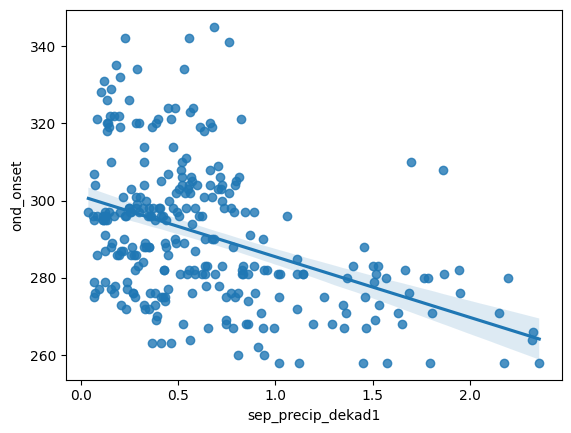

In [17]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["sep_precip_dekad1"] ** (1/2)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

-0.5089109821813408


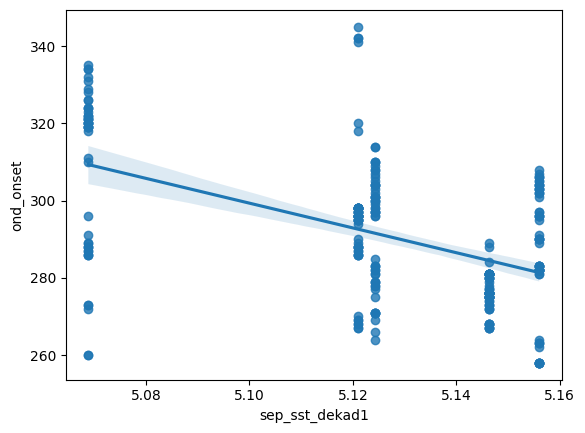

In [18]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["sep_sst_dekad1"] ** (1/2)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

-0.35392323872192527


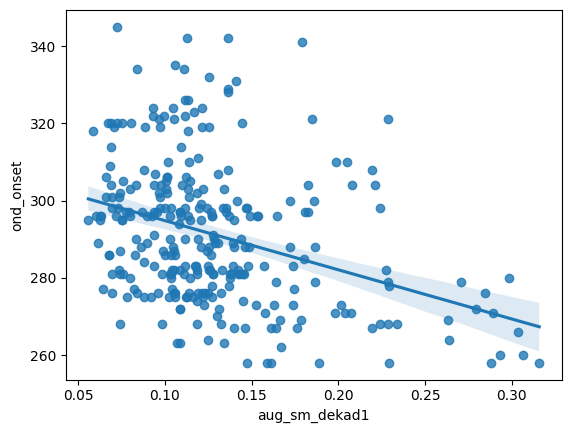

In [19]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["aug_sm_dekad1"] ** (1/1)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

-0.2545416229202729


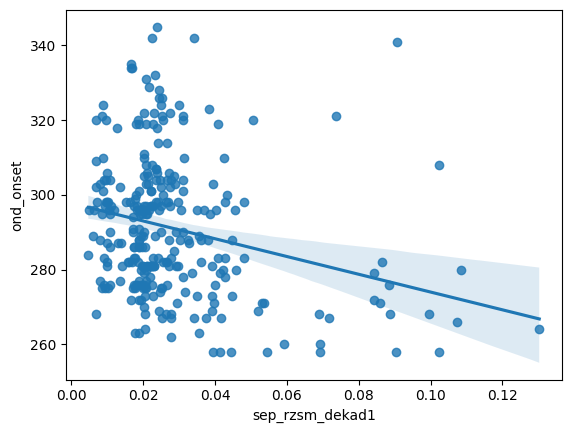

In [20]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "sep_rzsm_dekad1", "ond_onset"]].dropna()["sep_rzsm_dekad1"] ** (2)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "sep_rzsm_dekad1", "ond_onset"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

-0.4729569361158621


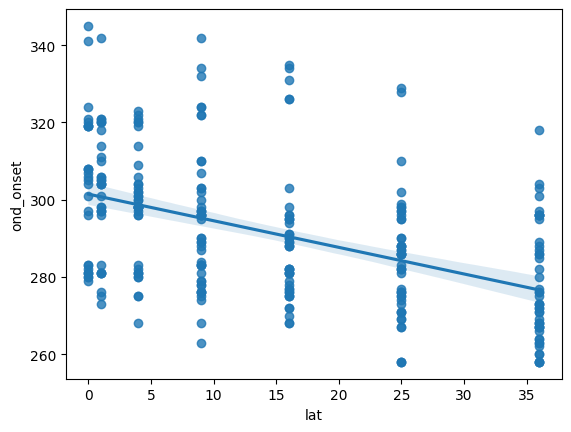

In [21]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["lat"] ** (2)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

-0.032532799573165246


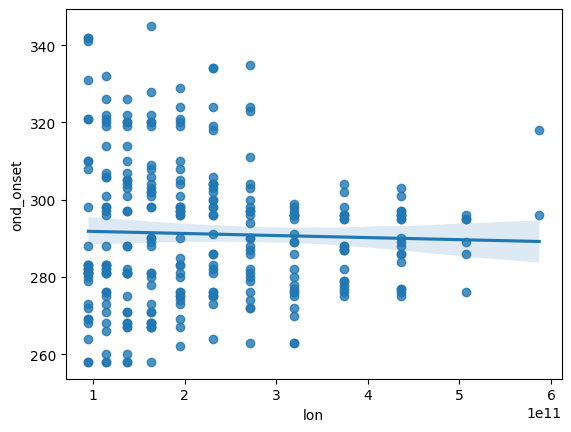

In [22]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["lon"] ** (7)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

In [23]:
engineered_model = run_lasso_model(df, ["lat_squared", "lon_seventh_power", 
                                        "sep_sst_dekad1_square_root", "sep_precip_dekad1_square_root", 
                                        "aug_sm_dekad1", "sep_rzsm_dekad1_squared", "lat", "lon", 
                                        "sep_sst_dekad1", "sep_precip_dekad1", "sep_rzsm_dekad1"])
engineered_model_test_df = engineered_model["test_df"]
engineered_model_test_df["test_predictions"] = engineered_model["test_predictions"]
engineered_model_test_df.head()

,lat_squared,lon_seventh_power,sep_sst_dekad1_square_root,sep_precip_dekad1_square_root,aug_sm_dekad1,sep_rzsm_dekad1_squared,lat,lon,sep_sst_dekad1,sep_precip_dekad1,sep_rzsm_dekad1,ond_onset,test_predictions
305,0,94931877133,5.127194,0.822955,0.165334,0.070545,0,37,26.288122,0.677255,0.265604,329.0,303.461249
306,0,114415582592,5.127194,0.181659,0.140087,0.041071,0,38,26.288122,0.033000,0.202660,328.0,312.829241
307,0,137231006679,5.127194,0.000000,0.100150,0.019410,0,39,26.288122,0.000000,0.139321,329.0,318.179395
308,0,163840000000,5.127194,0.294797,0.075278,0.018601,0,40,26.288122,0.086905,0.136386,329.0,313.103826
309,0,194754273881,5.127194,0.805003,0.113124,0.020260,0,41,26.288122,0.648030,0.142339,329.0,300.329606


In [24]:
print(f"RMSE: {engineered_model["rmse"]}")
print(f"R^2: {engineered_model["r2"]}")
print("\nFeature Coefficients:")
print(engineered_model["coef_df"].to_string(index=False))

RMSE: 20.812349059012423
R^2: 0.17405868507284983

Feature Coefficients:
                      feature  coefficient
sep_precip_dekad1_square_root   -12.113356
            sep_precip_dekad1     7.111342
   sep_sst_dekad1_square_root    -6.875051
                          lat    -6.328618
                aug_sm_dekad1    -4.785300
      sep_rzsm_dekad1_squared     3.997475
              sep_rzsm_dekad1    -1.982476
                          lon    -1.807560
                  lat_squared    -1.569261
            lon_seventh_power    -0.469088
               sep_sst_dekad1    -0.013895


In [25]:
baseline_mean = np.full(
    len(engineered_model_test_df),
    engineered_model["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(engineered_model_test_df["ond_onset"], engineered_model_test_df["test_predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(engineered_model_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.1955


In [26]:
# graph(engineered_model)

In [27]:
extended_engineered_model = run_lasso_model(df, ["lat_squared", "lon_seventh_power", 
                                                 "sep_sst_dekad1_square_root", "sep_precip_dekad1_square_root", 
                                                 "aug_sm_dekad1", "sep_rzsm_dekad1_squared", "lat", "lon", 
                                                 "sep_sst_dekad1", "sep_precip_dekad1", "aug_rzsm_dekad1", 
                                                 "aug_sst_dekad1", "aug_sst_dekad2", "aug_sst_dekad3", 
                                                 "aug_precip_dekad1", "aug_precip_dekad2", "aug_precip_dekad3", 
                                                 "aug_rzsm_dekad2", "aug_rzsm_dekad3", "sep_rzsm_dekad1"])
extended_engineered_model_test_df = extended_engineered_model["test_df"]
extended_engineered_model_test_df["test_predictions"] = extended_engineered_model["test_predictions"]
extended_engineered_model_test_df.head()

,lat_squared,lon_seventh_power,sep_sst_dekad1_square_root,sep_precip_dekad1_square_root,aug_sm_dekad1,sep_rzsm_dekad1_squared,lat,lon,sep_sst_dekad1,sep_precip_dekad1,...,aug_sst_dekad2,aug_sst_dekad3,aug_precip_dekad1,aug_precip_dekad2,aug_precip_dekad3,aug_rzsm_dekad2,aug_rzsm_dekad3,sep_rzsm_dekad1,ond_onset,test_predictions
305,0,94931877133,5.127194,0.822955,0.165334,0.070545,0,37,26.288122,0.677255,...,26.11574,26.156958,0.925280,1.222985,1.868914,0.268088,0.262650,0.265604,329.0,301.409818
306,0,114415582592,5.127194,0.181659,0.140087,0.041071,0,38,26.288122,0.033000,...,26.11574,26.156958,0.057345,0.090075,0.103164,0.209683,0.205849,0.202660,328.0,305.279870
307,0,137231006679,5.127194,0.000000,0.100150,0.019410,0,39,26.288122,0.000000,...,26.11574,26.156958,0.000000,0.001930,0.000000,0.141270,0.140309,0.139321,329.0,307.618978
308,0,163840000000,5.127194,0.294797,0.075278,0.018601,0,40,26.288122,0.086905,...,26.11574,26.156958,0.004685,0.038165,0.000000,0.137942,0.136961,0.136386,329.0,307.320544
309,0,194754273881,5.127194,0.805003,0.113124,0.020260,0,41,26.288122,0.648030,...,26.11574,26.156958,0.111720,0.101845,0.010014,0.135944,0.135220,0.142339,329.0,303.660360


In [28]:
print(f"RMSE: {extended_engineered_model["rmse"]}")
print(f"R^2: {extended_engineered_model["r2"]}")
print("\nFeature Coefficients:")
print(extended_engineered_model["coef_df"].to_string(index=False))

RMSE: 20.210510147049376
R^2: 0.2211361619385439

Feature Coefficients:
                      feature  coefficient
               aug_sst_dekad1    -5.186193
                          lat    -4.926215
sep_precip_dekad1_square_root    -2.119894
                aug_sm_dekad1    -1.985151
   sep_sst_dekad1_square_root    -1.189855
                  lat_squared    -0.614030
            aug_precip_dekad3    -0.091319
            lon_seventh_power    -0.000000
                          lon    -0.000000
               sep_sst_dekad1    -0.000000
            sep_precip_dekad1    -0.000000
      sep_rzsm_dekad1_squared    -0.000000
              aug_rzsm_dekad1    -0.000000
               aug_sst_dekad2    -0.000000
            aug_precip_dekad1    -0.000000
               aug_sst_dekad3    -0.000000
            aug_precip_dekad2    -0.000000
              aug_rzsm_dekad2    -0.000000
              aug_rzsm_dekad3    -0.000000
              sep_rzsm_dekad1    -0.000000


In [29]:
baseline_mean = np.full(
    len(extended_engineered_model_test_df),
    extended_engineered_model["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(extended_engineered_model_test_df["ond_onset"], extended_engineered_model_test_df["test_predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(extended_engineered_model_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.2187


In [30]:
# graph(extended_engineered_model)

-0.5189761238667987


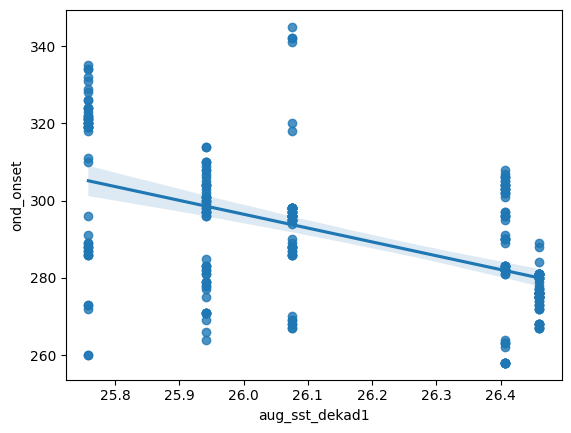

In [31]:
x = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset", "aug_sst_dekad1"]].dropna()["aug_sst_dekad1"] ** (1/1)
y = df[df["year"] <= 2020][["lat", "lon", "sep_sst_dekad1", 
"sep_precip_dekad1", "aug_sm_dekad1", "aug_rzsm_dekad1", "ond_onset", "aug_sst_dekad1"]].dropna()["ond_onset"]
corr = np.corrcoef(x, y)[0, 1]
print(corr)
sns.regplot(df, x=x, y=y);

In [32]:
best_model = run_lasso_model(df, ["lat_squared",
                                 "sep_sst_dekad1_square_root", "sep_precip_dekad1_square_root", 
                                 "aug_sm_dekad1", "lat",
                                 "aug_sst_dekad1",
                                 "aug_precip_dekad3"])
best_model_test_df = best_model["test_df"]
best_model_test_df["test_predictions"] = best_model["test_predictions"]
best_model_test_df.head()

,lat_squared,sep_sst_dekad1_square_root,sep_precip_dekad1_square_root,aug_sm_dekad1,lat,aug_sst_dekad1,aug_precip_dekad3,ond_onset,test_predictions
305,0,5.127194,0.822955,0.165334,0,25.976824,1.868914,329.0,304.132498
306,0,5.127194,0.181659,0.140087,0,25.976824,0.103164,328.0,310.284313
307,0,5.127194,0.000000,0.100150,0,25.976824,0.000000,329.0,314.005593
308,0,5.127194,0.294797,0.075278,0,25.976824,0.000000,329.0,314.033576
309,0,5.127194,0.805003,0.113124,0,25.976824,0.010014,329.0,308.683359


In [33]:
print(f"RMSE: {best_model["rmse"]}")
print(f"R^2: {best_model["r2"]}")
print("\nFeature Coefficients:")
print(best_model["coef_df"].to_string(index=False))

RMSE: 19.873801362704686
R^2: 0.24687185473313333

Feature Coefficients:
                      feature  coefficient
                          lat    -7.348863
               aug_sst_dekad1    -6.869996
                aug_sm_dekad1    -3.406647
sep_precip_dekad1_square_root    -2.732591
   sep_sst_dekad1_square_root    -1.650749
            aug_precip_dekad3    -0.611262
                  lat_squared    -0.000000


In [34]:
baseline_mean = np.full(
    len(best_model_test_df),
    best_model["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(best_model_test_df["ond_onset"], best_model_test_df["test_predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(best_model_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.2317


In [35]:
model_with_ocean = run_lasso_model(df, ["lat_squared",
                     "sep_sst_dekad1_square_root", "sep_precip_dekad1_square_root", 
                     "aug_sm_dekad1", "lat","aug_sst_dekad1", "aug_precip_dekad3", 
                    "sep_tcwv_dekad1", "sep_msl_dekad1", "sep_10u_dekad1", "sep_10v_dekad1"])
model_with_ocean_test_df = model_with_ocean["test_df"]
model_with_ocean_test_df["test_predictions"] = model_with_ocean["test_predictions"]
model_with_ocean_test_df.head()

,lat_squared,sep_sst_dekad1_square_root,sep_precip_dekad1_square_root,aug_sm_dekad1,lat,aug_sst_dekad1,aug_precip_dekad3,sep_tcwv_dekad1,sep_msl_dekad1,sep_10u_dekad1,sep_10v_dekad1,ond_onset,test_predictions
305,0,5.127194,0.822955,0.165334,0,25.976824,1.868914,34.81768,101399.695312,-2.956316,5.896349,329.0,314.548371
306,0,5.127194,0.181659,0.140087,0,25.976824,0.103164,34.81768,101399.695312,-2.956316,5.896349,328.0,321.286848
307,0,5.127194,0.000000,0.100150,0,25.976824,0.000000,34.81768,101399.695312,-2.956316,5.896349,329.0,324.263752
308,0,5.127194,0.294797,0.075278,0,25.976824,0.000000,34.81768,101399.695312,-2.956316,5.896349,329.0,324.432029
309,0,5.127194,0.805003,0.113124,0,25.976824,0.010014,34.81768,101399.695312,-2.956316,5.896349,329.0,320.447733


In [36]:
print(f"RMSE: {model_with_ocean["rmse"]}")
print(f"R^2: {model_with_ocean["r2"]}")
print("\nFeature Coefficients:")
print(model_with_ocean["coef_df"].to_string(index=False))

RMSE: 19.54111141192314
R^2: 0.27187572523989867

Feature Coefficients:
                      feature  coefficient
              sep_tcwv_dekad1    -9.662301
                          lat    -7.094161
               sep_10v_dekad1    -3.070020
                aug_sm_dekad1    -2.690075
            aug_precip_dekad3    -1.940581
sep_precip_dekad1_square_root    -1.912791
               sep_10u_dekad1    -1.122987
   sep_sst_dekad1_square_root    -0.000000
                  lat_squared    -0.000000
               aug_sst_dekad1    -0.000000
               sep_msl_dekad1     0.000000


In [37]:
baseline_mean = np.full(
    len(model_with_ocean_test_df),
    model_with_ocean["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(model_with_ocean_test_df["ond_onset"], model_with_ocean_test_df["test_predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(model_with_ocean_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.2446


In [38]:
model_with_ocean_land = run_lasso_model(df, ["lat_squared",
                     "sep_sst_dekad1_square_root", "sep_precip_dekad1_square_root", 
                     "aug_sm_dekad1", "lat","aug_sst_dekad1", "aug_precip_dekad3", 
                    "sep_tcwv_dekad1", "sep_msl_dekad1", "sep_10u_dekad1", "sep_10v_dekad1", 
                                             "sep_2t_dekad1", "sep_2d_dekad1", "sep_cape_dekad1", "sep_tcc_dekad1"])
model_with_ocean_land_test_df = model_with_ocean_land["test_df"]
model_with_ocean_land_test_df["test_predictions"] = model_with_ocean_land["test_predictions"]
model_with_ocean_land_test_df.head()

,lat_squared,sep_sst_dekad1_square_root,sep_precip_dekad1_square_root,aug_sm_dekad1,lat,aug_sst_dekad1,aug_precip_dekad3,sep_tcwv_dekad1,sep_msl_dekad1,sep_10u_dekad1,sep_10v_dekad1,sep_2t_dekad1,sep_2d_dekad1,sep_cape_dekad1,sep_tcc_dekad1,ond_onset,test_predictions
305,0,5.127194,0.822955,0.165334,0,25.976824,1.868914,34.81768,101399.695312,-2.956316,5.896349,289.222748,284.682922,24.385937,0.688840,329.0,303.120458
306,0,5.127194,0.181659,0.140087,0,25.976824,0.103164,34.81768,101399.695312,-2.956316,5.896349,295.600433,287.090881,6.230404,0.619848,328.0,307.751596
307,0,5.127194,0.000000,0.100150,0,25.976824,0.000000,34.81768,101399.695312,-2.956316,5.896349,300.133240,289.820374,2.016536,0.560729,329.0,310.846009
308,0,5.127194,0.294797,0.075278,0,25.976824,0.000000,34.81768,101399.695312,-2.956316,5.896349,300.620300,291.581665,5.601498,0.621107,329.0,309.220211
309,0,5.127194,0.805003,0.113124,0,25.976824,0.010014,34.81768,101399.695312,-2.956316,5.896349,300.926331,292.476501,6.101172,0.580264,329.0,309.135717


In [39]:
print(f"RMSE: {model_with_ocean_land["rmse"]}")
print(f"R^2: {model_with_ocean_land["r2"]}")
print("\nFeature Coefficients:")
print(model_with_ocean_land["coef_df"].to_string(index=False))

RMSE: 18.357032311697075
R^2: 0.35744259456026317

Feature Coefficients:
                      feature  coefficient
                          lat    -5.994856
               sep_tcc_dekad1    -3.855748
              sep_tcwv_dekad1    -3.578903
               aug_sst_dekad1    -3.148013
                aug_sm_dekad1    -1.219226
            aug_precip_dekad3    -0.797527
                  lat_squared    -0.689388
sep_precip_dekad1_square_root    -0.470576
   sep_sst_dekad1_square_root    -0.222644
               sep_10u_dekad1    -0.000000
               sep_msl_dekad1     0.000000
               sep_10v_dekad1    -0.000000
                sep_2t_dekad1    -0.000000
                sep_2d_dekad1    -0.000000
              sep_cape_dekad1    -0.000000


In [40]:
baseline_mean = np.full(
    len(model_with_ocean_land_test_df),
    model_with_ocean_land["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(model_with_ocean_land_test_df["ond_onset"], model_with_ocean_land_test_df["test_predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(model_with_ocean_land_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.2904


In [41]:
greatest_model = run_lasso_model(df, ["lat_squared",
                     "sep_sst_dekad1_square_root", "sep_precip_dekad1_square_root", 
                     "aug_sm_dekad1", "lat","aug_sst_dekad1", "aug_precip_dekad3", 
                    "sep_tcwv_dekad1", "sep_tcc_dekad1"])
greatest_model_test_df = greatest_model["test_df"]
greatest_model_test_df["predictions"] = greatest_model["test_predictions"]
greatest_model_train_df = greatest_model["train_df"]
greatest_model_train_df["predictions"] = greatest_model["train_predictions"]
greatest_model_test_df.head()

,lat_squared,sep_sst_dekad1_square_root,sep_precip_dekad1_square_root,aug_sm_dekad1,lat,aug_sst_dekad1,aug_precip_dekad3,sep_tcwv_dekad1,sep_tcc_dekad1,ond_onset,predictions
305,0,5.127194,0.822955,0.165334,0,25.976824,1.868914,34.81768,0.688840,329.0,304.996012
306,0,5.127194,0.181659,0.140087,0,25.976824,0.103164,34.81768,0.619848,328.0,311.139392
307,0,5.127194,0.000000,0.100150,0,25.976824,0.000000,34.81768,0.560729,329.0,315.194443
308,0,5.127194,0.294797,0.075278,0,25.976824,0.000000,34.81768,0.621107,329.0,313.485841
309,0,5.127194,0.805003,0.113124,0,25.976824,0.010014,34.81768,0.580264,329.0,313.129083


In [42]:
print(f"RMSE: {greatest_model["rmse"]}")
print(f"R^2: {greatest_model["r2"]}")
print("\nFeature Coefficients:")
print(greatest_model["coef_df"].to_string(index=False))

RMSE: 17.776894143841112
R^2: 0.39741438333910917

Feature Coefficients:
                      feature  coefficient
                          lat    -7.877825
               sep_tcc_dekad1    -4.632376
              sep_tcwv_dekad1    -4.183268
               aug_sst_dekad1    -3.769282
                aug_sm_dekad1    -1.891879
            aug_precip_dekad3    -1.255485
sep_precip_dekad1_square_root    -0.503729
   sep_sst_dekad1_square_root    -0.338566
                  lat_squared    -0.079029


In [43]:
baseline_mean = np.full(
    len(greatest_model_test_df),
    greatest_model["train_df"]["ond_onset"].mean(),
    dtype=float
)
rmse_model = np.sqrt(
    mean_squared_error(greatest_model_test_df["ond_onset"], greatest_model_test_df["predictions"])
)
rmse_baseline = np.sqrt(
    mean_squared_error(greatest_model_test_df["ond_onset"], baseline_mean)
)
skill_rmse = 1 - (rmse_model / rmse_baseline)
print(f"RMSE Skill Score: {skill_rmse:.4f}")

RMSE Skill Score: 0.3128


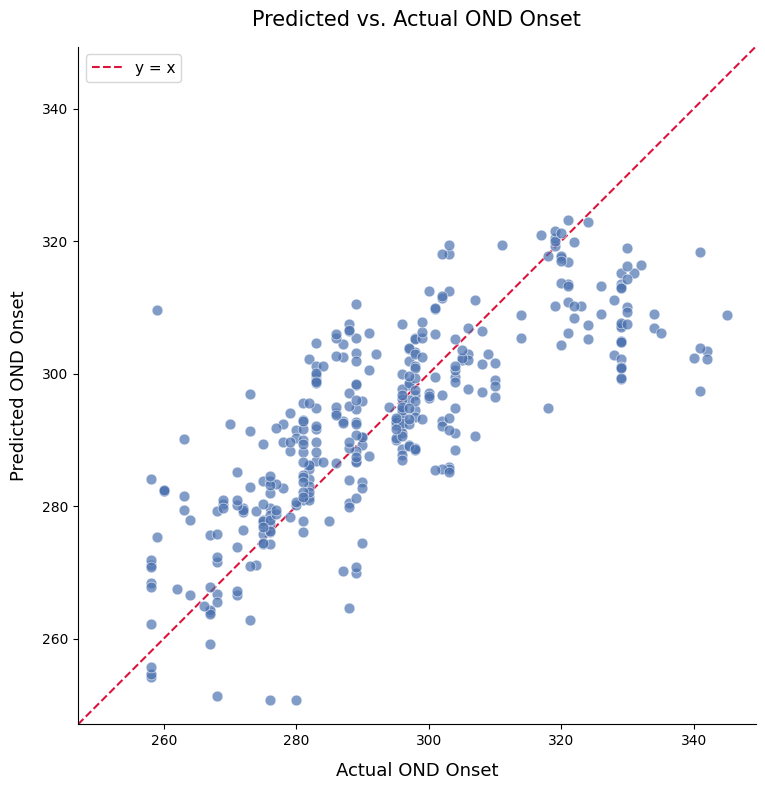

In [44]:
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter plot
sns.scatterplot(
    data=pd.concat([greatest_model_train_df, greatest_model_test_df]),
    x="ond_onset",
    y="predictions",
    alpha=0.7,
    edgecolor="white",
    linewidth=0.5,
    s=60,
    color="#4C72B0",
    ax=ax
)

# y = x reference line
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()])
]
ax.plot(lims, lims, color="crimson", linewidth=1.5, linestyle="--", zorder=0, label="y = x")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

# Labels & title
ax.set_xlabel("Actual OND Onset", fontsize=13, labelpad=10)
ax.set_ylabel("Predicted OND Onset", fontsize=13, labelpad=10)
ax.set_title("Predicted vs. Actual OND Onset", fontsize=15, pad=15)

ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig("best_model_scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

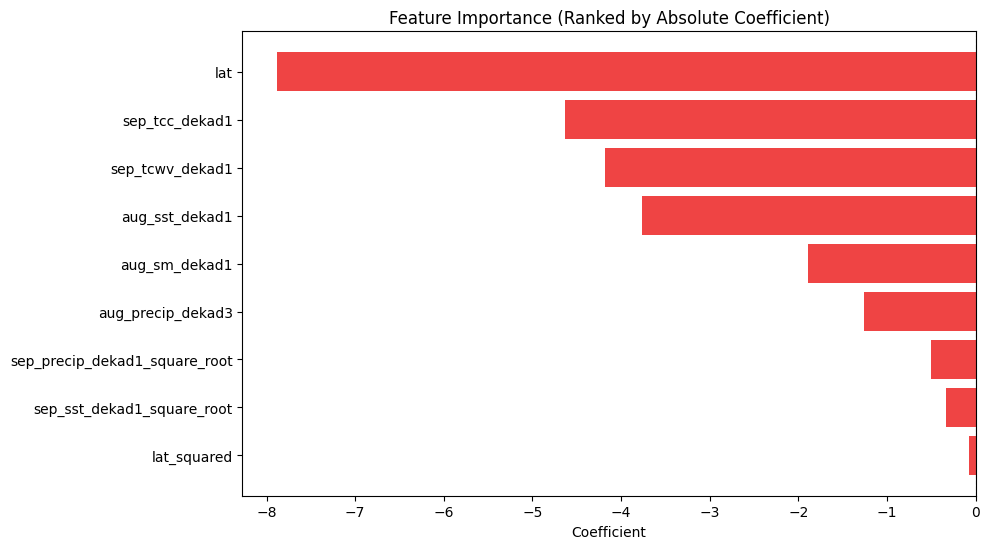

In [45]:
coef_df = greatest_model["coef_df"].copy()
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values().index)

colors = ["#ef4444" if c < 0 else "#3b82f6" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(10, len(coef_df) * 0.4 + 2))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Coefficient")
ax.set_title("Feature Importance (Ranked by Absolute Coefficient)")
plt.tight_layout()
plt.show()

In [46]:
def graph(model, df):
    lat_full = np.arange(-1, 8)
    lon_full = np.arange(36, 50)
    proj = ccrs.PlateCarree()

    model_train_df = model["train_df"].copy()
    model_train_df["predictions"] = model["train_predictions"]

    model_test_df = model["test_df"].copy()
    model_test_df["predictions"] = model["test_predictions"]

    model_df = pd.concat([model_train_df, model_test_df])

    spatial_cols = ["lat", "lon", "ond_onset"]
    model_df = model_df.join(
        df[spatial_cols].loc[model_df.index], how="left", rsuffix="_orig"
    )

    # if "lat_orig" in model_df.columns:
    #     model_df["lat"] = model_df["lat_orig"]
    #     model_df["lon"] = model_df["lon_orig"]
    #     model_df = model_df.drop(columns=["lat_orig", "lon_orig"])

    # if "ond_onset_orig" in model_df.columns:
    #     model_df["ond_onset"] = model_df["ond_onset_orig"]
    #     model_df = model_df.drop(columns=["ond_onset_orig"])

    per_cell_rmse = (
        model_df.groupby(["lat", "lon"])
        .apply(lambda g: np.sqrt(np.mean((g["ond_onset"] - g["predictions"]) ** 2)))
        .reset_index()
        .rename(columns={0: "rmse"})
    )

    pivot = (
        per_cell_rmse.pivot(index="lat", columns="lon", values="rmse")
        .reindex(index=lat_full, columns=lon_full)
    )

    R    = pivot.values
    lats = pivot.index.values
    lons = pivot.columns.values
    lon2d, lat2d = np.meshgrid(lons, lats)

    fig = plt.figure(figsize=(10, 6))
    ax  = plt.axes(projection=proj)
    pcm = ax.pcolormesh(
        lon2d, lat2d, R,
        cmap="YlOrRd",
        shading="auto", transform=proj
    )

    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            val = R[i, j]
            if np.isnan(val):
                continue
            ax.text(
                lon, lat, f"{val:.1f}",
                ha="center", va="center",
                fontsize=6, color="black",
                transform=proj,
            )

    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND,    facecolor="lightgrey", zorder=0)
    ax.add_feature(cfeature.OCEAN,   facecolor="lightblue", zorder=0)
    ax.set_extent(
        [lon_full[0]-0.5, lon_full[-1]+0.5,
         lat_full[0]-0.5, lat_full[-1]+0.5],
        crs=proj
    )
    ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", color="grey")

    plt.colorbar(pcm, ax=ax, label="RMSE (days)", shrink=0.85)
    ax.set_title("Per-Cell RMSE OND Onset Predictions", fontsize=12)
    plt.tight_layout()
    plt.savefig("model_rmse_spatial_map.png", dpi=300, bbox_inches="tight")
    plt.show()

/tmp/ipykernel_259900/3447480991.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.sqrt(np.mean((g["ond_onset"] - g["predictions"]) ** 2)))


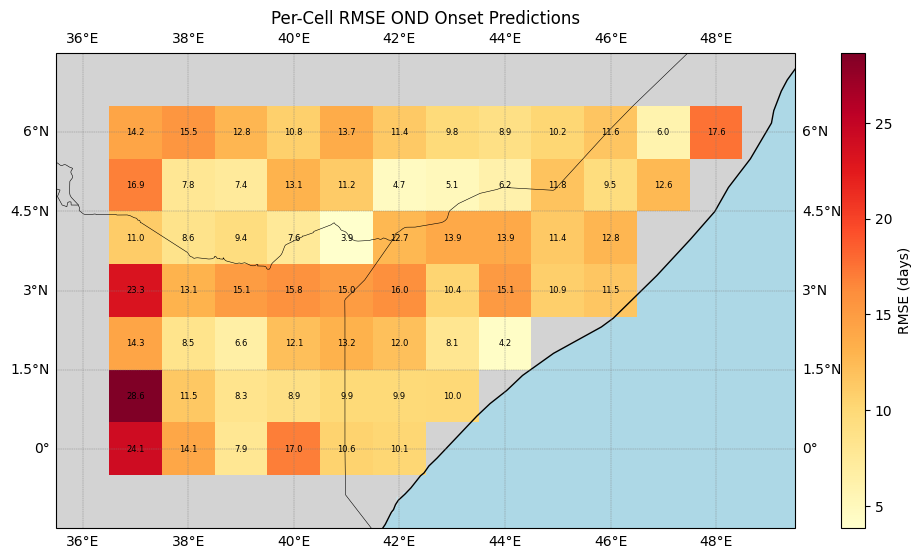

In [47]:
graph(greatest_model, df)

In [50]:
def skill_score_spatial(model, df):
    model_train_df = model["train_df"].copy()
    model_train_df["predictions"] = model["train_predictions"]
    model_test_df = model["test_df"].copy()
    model_test_df["predictions"] = model["test_predictions"]

    spatial_cols = ["lat", "lon", "ond_onset"]

    # Join lat/lon/ond_onset from original df
    model_train_df = model_train_df.join(
        df[spatial_cols].loc[model_train_df.index], how="left", rsuffix="_orig"
    )
    model_test_df = model_test_df.join(
        df[spatial_cols].loc[model_test_df.index], how="left", rsuffix="_orig"
    )

    # Compute per-(lat, lon) mean from training data only
    cell_means = (
        model_train_df
        .groupby(["lat", "lon"])["ond_onset"]
        .mean()
        .rename("baseline_mean")
        .reset_index()
    )

    # Merge baseline mean into test set
    model_test_df = model_test_df.merge(cell_means, on=["lat", "lon"], how="left")

    # Fall back to global train mean for any cells not seen in training
    global_mean = model_train_df["ond_onset"].mean()
    model_test_df["baseline_mean"] = model_test_df["baseline_mean"].fillna(global_mean)

    # Compute skill score
    rmse_model = np.sqrt(mean_squared_error(model_test_df["ond_onset"], model_test_df["predictions"]))
    rmse_baseline = np.sqrt(mean_squared_error(model_test_df["ond_onset"], model_test_df["baseline_mean"]))

    skill_rmse = 1 - (rmse_model / rmse_baseline)
    print(f"RMSE (model):    {rmse_model:.4f}")
    print(f"RMSE (baseline): {rmse_baseline:.4f}")
    print(f"RMSE Skill Score: {skill_rmse:.4f}")

    return skill_rmse, model_test_df

In [53]:
skill_score_spatial(greatest_model, df)

RMSE (model):    17.7769
RMSE (baseline): 20.2867
RMSE Skill Score: 0.1237


(np.float64(0.12371625570653288),
     lat_squared  sep_sst_dekad1_square_root  sep_precip_dekad1_square_root  \
 0             0                    5.127194                       0.822955   
 1             0                    5.127194                       0.181659   
 2             0                    5.127194                       0.000000   
 3             0                    5.127194                       0.294797   
 4             0                    5.127194                       0.805003   
 ..          ...                         ...                            ...   
 70           36                    5.081719                       1.477987   
 71           36                    5.081719                       0.273870   
 72           36                    5.081719                       0.033690   
 73           36                    5.081719                       0.023979   
 74           36                    5.081719                       0.013601   
 
     aug_sm_deka